In [16]:
# Importing required libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [17]:
# Loading the feature-engineered dataset
data = pd.read_csv("../data/model_ready_data.csv")
data.head()

,Country Name,year,temp_anomaly,lag_1,rolling_mean_5,decade,country_encoded
0,"Afghanistan, Islamic Rep. of",1971,0.652,0.898,0.775000,1970,0
1,"Afghanistan, Islamic Rep. of",1972,-1.089,0.652,0.153667,1970,0
2,"Afghanistan, Islamic Rep. of",1973,0.262,-1.089,0.180750,1970,0
3,"Afghanistan, Islamic Rep. of",1974,-0.470,0.262,0.050600,1970,0
4,"Afghanistan, Islamic Rep. of",1975,-0.468,-0.470,-0.222600,1970,0


In [18]:
# Defining input features and the target variable — same as used for XGBoost
features = ["year", "lag_1", "rolling_mean_5", "decade", "country_encoded"]
target = "temp_anomaly"

X = data[features]
y = data[target]

In [19]:
# Splitting by year instead of randomly, same approach as XGBoost, for a fair comparison
train_data = data[data["year"] <= 2015]
test_data = data[data["year"] > 2015]

X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

In [20]:
# Creating and training a single Linear Regression model across all countries
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.01,-0.14, 1.12,-0.01,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['year','lag_1','rolling_mean_5','decade','country_encoded']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.214
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [21]:
# Predicting temperature change for every country from 2022 to 2050, one year at a time
future_years = list(range(2022, 2051))
results = []

for country in data["Country Name"].unique():
    country_data = data[data["Country Name"] == country].sort_values("year")
    country_code = country_data["country_encoded"].iloc[0]

    history = country_data["temp_anomaly"].tolist()
    row_result = {"Country": country}

    for year in future_years:
        lag_1 = history[-1]
        rolling_mean_5 = np.mean(history[-5:])
        decade = (year // 10) * 10

        input_row = pd.DataFrame([{
            "year": year,
            "lag_1": lag_1,
            "rolling_mean_5": rolling_mean_5,
            "decade": decade,
            "country_encoded": country_code
        }])

        pred = model.predict(input_row)[0]
        row_result[str(year)] = pred
        history.append(pred)

    results.append(row_result)

pred_data = pd.DataFrame(results)
pred_data.head()

,Country,2022,2023,2024,2025,2026,2027,2028,2029,2030,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,"Afghanistan, Islamic Rep. of",1.249271,1.213270,1.147885,1.210793,1.363389,1.341376,1.376872,1.420493,1.385243,...,1.761092,1.799183,1.837747,1.873843,1.906825,1.958176,2.007122,2.058831,2.113105,2.068922
1,Albania,1.766794,1.878523,1.815099,1.833872,1.890379,1.941149,1.985083,2.014765,1.965086,...,2.312914,2.348233,2.383678,2.416905,2.447093,2.495650,2.541765,2.590635,2.642133,2.595187
2,Algeria,1.565325,1.695416,1.797931,1.953413,1.952965,1.883304,1.975946,2.037921,1.992844,...,2.321096,2.356743,2.392374,2.425336,2.455369,2.503896,2.550029,2.598841,2.650238,2.603232
3,American Samoa,0.842137,0.832976,0.904094,0.901712,0.933304,1.003608,1.041974,1.095372,1.040558,...,1.439905,1.479802,1.519720,1.557417,1.592020,1.645039,1.695560,1.748804,1.804660,1.762048
4,"Andorra, Principality of",1.937585,1.908432,1.957304,1.994765,1.910446,2.055615,2.073973,2.120380,2.060208,...,2.400652,2.435693,2.470404,2.503178,2.532839,2.580955,2.626586,2.674930,2.725956,2.678526


In [22]:
pred_data

,Country,2022,2023,2024,2025,2026,2027,2028,2029,2030,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,"Afghanistan, Islamic Rep. of",1.249271,1.213270,1.147885,1.210793,1.363389,1.341376,1.376872,1.420493,1.385243,...,1.761092,1.799183,1.837747,1.873843,1.906825,1.958176,2.007122,2.058831,2.113105,2.068922
1,Albania,1.766794,1.878523,1.815099,1.833872,1.890379,1.941149,1.985083,2.014765,1.965086,...,2.312914,2.348233,2.383678,2.416905,2.447093,2.495650,2.541765,2.590635,2.642133,2.595187
2,Algeria,1.565325,1.695416,1.797931,1.953413,1.952965,1.883304,1.975946,2.037921,1.992844,...,2.321096,2.356743,2.392374,2.425336,2.455369,2.503896,2.550029,2.598841,2.650238,2.603232
3,American Samoa,0.842137,0.832976,0.904094,0.901712,0.933304,1.003608,1.041974,1.095372,1.040558,...,1.439905,1.479802,1.519720,1.557417,1.592020,1.645039,1.695560,1.748804,1.804660,1.762048
4,"Andorra, Principality of",1.937585,1.908432,1.957304,1.994765,1.910446,2.055615,2.073973,2.120380,2.060208,...,2.400652,2.435693,2.470404,2.503178,2.532839,2.580955,2.626586,2.674930,2.725956,2.678526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,Western Sahara,1.638275,1.540440,1.720173,1.772355,1.720203,1.775764,1.810780,1.878382,1.814210,...,2.126766,2.159967,2.192999,2.223788,2.251513,2.297777,2.341580,2.388097,2.437262,2.388002
223,World,1.512860,1.534882,1.599907,1.636630,1.626318,1.680868,1.722861,1.771051,1.712442,...,2.033934,2.067489,2.100983,2.132255,2.160489,2.207186,2.251431,2.298408,2.348032,2.299225
224,"Yemen, Rep. of",0.132461,0.150502,0.179917,0.214361,0.255832,0.305630,0.349431,0.399827,0.351841,...,0.750717,0.790843,0.831026,0.868927,0.903740,0.956955,1.007696,1.061155,1.117216,1.074810
225,Zambia,1.054484,1.133834,1.225931,1.209655,1.214240,1.273001,1.325732,1.373327,1.309478,...,1.657217,1.692661,1.728059,1.761225,1.791385,1.839988,1.886105,1.934954,1.986442,1.939495


In [23]:
# Making predictions on the test set and checking accuracy
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 0.23070338497119386
R² Score: 0.7140452894871395


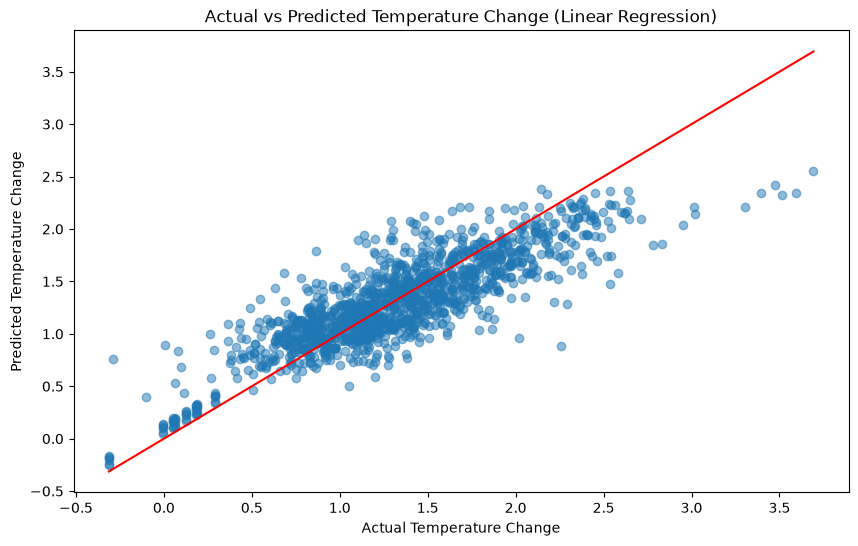

In [24]:
# Comparing actual vs predicted temperature change values
plt.figure(figsize=(10,6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual Temperature Change")
plt.ylabel("Predicted Temperature Change")
plt.title("Actual vs Predicted Temperature Change (Linear Regression)")
plt.show()

In [25]:
# Average predicted temperature per year, printed
mean_per_year = pred_data[[str(y) for y in future_years]].mean()
mean_df = mean_per_year.reset_index()
mean_df.columns = ["Year", "Mean_Temp_Change"]
print(mean_df)

    Year  Mean_Temp_Change
0   2022          1.381751
1   2023          1.414183
2   2024          1.459401
3   2025          1.483838
4   2026          1.492939
5   2027          1.552648
6   2028          1.594581
7   2029          1.641081
8   2030          1.585064
9   2031          1.627270
10  2032          1.663413
11  2033          1.695107
12  2034          1.725118
13  2035          1.751665
14  2036          1.797186
15  2037          1.840845
16  2038          1.886445
17  2039          1.934893
18  2040          1.884904
19  2041          1.933455
20  2042          1.969160
21  2043          2.004846
22  2044          2.038314
23  2045          2.068730
24  2046          2.117579
25  2047          2.163966
26  2048          2.213083
27  2049          2.264835
28  2050          2.218143


In [26]:
# Highest predicted country by 2050
max_row = pred_data.loc[pred_data["2050"].idxmax()]
print(max_row["Country"], max_row["2050"])

Estonia, Rep. of 3.2585008795802324


In [27]:
# Lowest predicted country by 2050
min_row = pred_data.loc[pred_data["2050"].idxmin()]
print(min_row["Country"], min_row["2050"])

Nauru, Rep. of 0.7919102946620589


In [28]:
# Countries predicted to exceed 2°C rise by 2050
baseline = data[data["year"] == 1971][["Country Name", "temp_anomaly"]].rename(columns={"temp_anomaly": "baseline"})
merged = pred_data.merge(baseline, left_on="Country", right_on="Country Name")
merged["rise_2050"] = merged["2050"] - merged["baseline"]
countries_over_2_2050 = merged[merged["rise_2050"] > 2]["Country"]

print("Number of countries with >2°C rise in 2050:", len(countries_over_2_2050))
print(countries_over_2_2050.tolist())

Number of countries with >2°C rise in 2050: 180
['Albania', 'Algeria', 'American Samoa', 'Andorra, Principality of', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia, Rep. of', 'Aruba, Kingdom of the Netherlands', 'Australia', 'Austria', 'Azerbaijan, Rep. of', 'Bahamas, The', 'Bahrain, Kingdom of', 'Bangladesh', 'Barbados', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'British Virgin Islands', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Cayman Islands', 'Central African Rep.', 'Chad', 'Chile', 'China, P.R.: Hong Kong', 'China, P.R.: Macao', 'China, P.R.: Mainland', 'Colombia', 'Comoros, Union of the', 'Congo, Dem. Rep. of the', 'Congo, Rep. of', 'Cook Islands', 'Cuba', 'Cyprus', 'Czech Rep.', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Rep.', 'Ecuador', 'Egypt, Arab Rep. of', 'El Salvador', 'Equatorial Guinea, Rep. of', 'Ethiopia, The Federal Dem. Rep. of', 'Finland', 'Fr

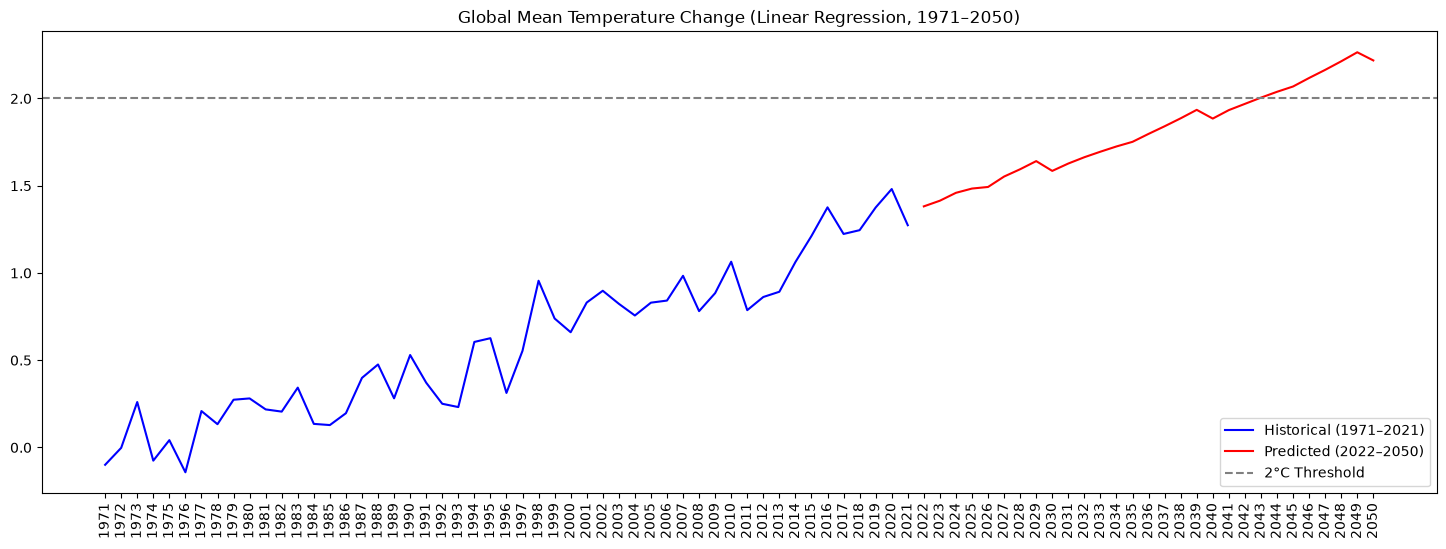

In [29]:
# Historical + predicted line graph
# Note: year 1970 was dropped earlier (no lag_1 available for the first year), so historical data starts from 1971
historical_years = sorted(data["year"].unique())

historical_mean = data.pivot(index="Country Name", columns="year", values="temp_anomaly")[historical_years].mean()
future_mean = pred_data[[str(y) for y in future_years]].mean()

plt.figure(figsize=(18,6))
plt.plot([str(y) for y in historical_years], historical_mean.values, color="blue", label="Historical (1971–2021)")
plt.plot([str(y) for y in future_years], future_mean.values, color="red", label="Predicted (2022–2050)")
plt.axhline(2, color="gray", linestyle="--", label="2°C Threshold")
plt.xticks(rotation=90)
plt.legend()
plt.title("Global Mean Temperature Change (Linear Regression, 1971–2050)")
plt.show()